In [3]:
import ast
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

# Plot insert and search times

In [5]:
benchmark_rows = []

with open("benchmark_results.text", "r") as f:
    lines = f.readlines()[1:]  # skip header

for line in lines:
    line = line.strip()
    # Skip empty lines
    if not line:
        continue
    # Find the first "{"
    start = line.find("{")
    # Extract only the dictionary portion
    dict_part = line[start:]
    # Convert safely to Python dict
    benchmark_rows.append(ast.literal_eval(dict_part))

bench_df = pd.DataFrame(benchmark_rows)

print(bench_df.head())

         dataset  items  insert_time  lookup_time
0  english_words   1000     0.003315     0.004652
1  english_words  10000     0.028309     0.032489
2  english_words  50000     0.136129     0.166881
3      sentences    100     0.000290     0.000304
4      sentences   1000     0.002687     0.003060


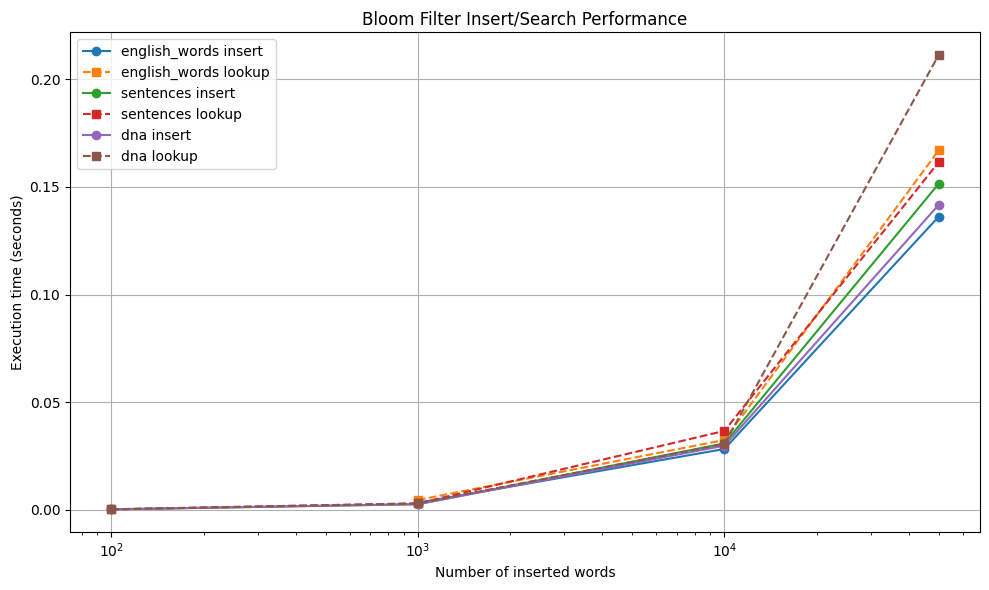

In [7]:

plt.figure(figsize=(10, 6))

datasets = bench_df["dataset"].unique()

for dataset in datasets:
    subset = bench_df[bench_df["dataset"] == dataset]

    plt.plot(
        subset["items"],
        subset["insert_time"],
        marker="o",
        label=f"{dataset} insert"
    )

    plt.plot(
        subset["items"],
        subset["lookup_time"],
        marker="s",
        linestyle="--",
        label=f"{dataset} lookup"
    )

plt.xscale("log")

plt.xlabel("Number of inserted words")
plt.ylabel("Execution time (seconds)")
plt.title("Bloom Filter Insert/Search Performance")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("benchmark_times.png", dpi=300)


# Plot FPR

In [9]:

with open("fpr_results.json", "r") as f:
    fpr_data = json.load(f)

fpr_df = pd.DataFrame(fpr_data)


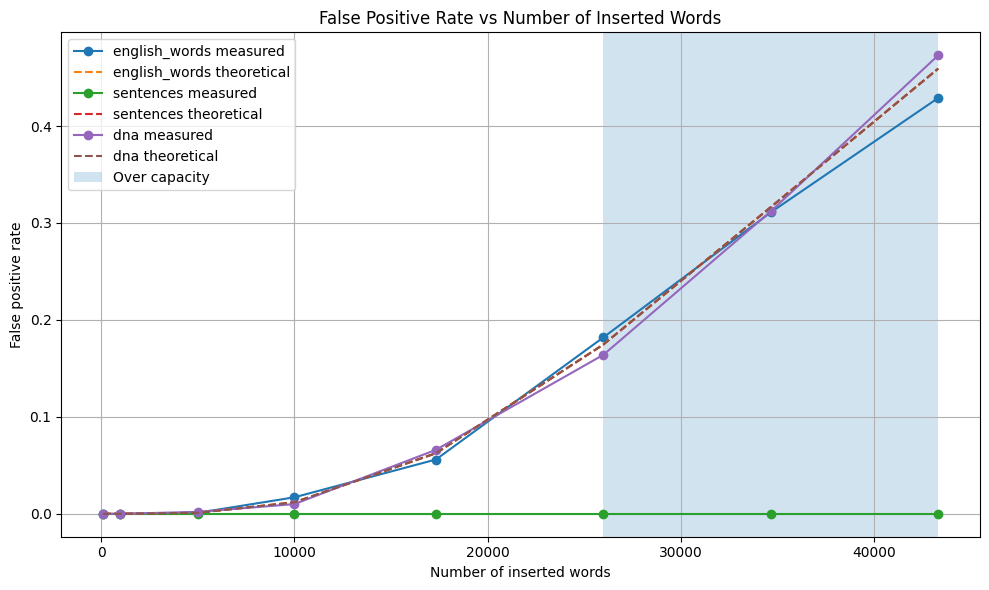

In [10]:
plt.figure(figsize=(10, 6))

for dataset in fpr_df["dataset"].unique():

    subset = fpr_df[fpr_df["dataset"] == dataset]

    plt.plot(
        subset["n_inserted"],
        subset["fpr_measured"],
        marker="o",
        label=f"{dataset} measured"
    )

    plt.plot(
        subset["n_inserted"],
        subset["fpr_theoretical"],
        linestyle="--",
        label=f"{dataset} theoretical"
    )

# highlight over-capacity region
over = fpr_df[fpr_df["over_capacity"] == True]

if not over.empty:
    plt.axvspan(
        over["n_inserted"].min(),
        over["n_inserted"].max(),
        alpha=0.2,
        label="Over capacity"
    )

plt.xlabel("Number of inserted words")
plt.ylabel("False positive rate")
plt.title("False Positive Rate vs Number of Inserted Words")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("false_positive_rate.png", dpi=300)

# Comression rate

compression_rate = bloom_filter_size_bits / exact_storage_bits

Exact storage estimate: average_word_length * 8 bits

Bloom filter size formula:
$$m = -(n * ln(p)) / (ln(2)^2)$$

where:
    $n$ = expected number of items
    $p$ = desired false positive probability